# Etapa 7 - Modelado predictivo de satisfacción

Ejecutar todas las celdas en orden desde el repositorio o notebooks/. Dependencias: pandas, openpyxl, numpy, scikit-learn, matplotlib e IPython. Genera reports/07_modelado.md y cinco figuras. Solo se lee el procesado; la imputación ocurre dentro de los pipelines. No se guardan modelos para uso externo ni se modifican archivos anteriores.

In [1]:
from pathlib import Path
import hashlib,re,platform
import pandas as pd
import numpy as np
import sklearn
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,mean_absolute_error,classification_report,confusion_matrix,ConfusionMatrixDisplay,make_scorer
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display,Markdown,Image
root=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"data/processed/dataset_salud_publica_limpio.xlsx").exists())
source=root/"data/processed/dataset_salud_publica_limpio.xlsx"
protected=[source,root/"dataset_salud_publica_2500.xlsx",root/"data/analysis/dataset_salud_vulnerabilidad.xlsx"]+[p for folder in ["reports","notebooks"] for p in (root/folder).glob("0[123456]*") if p.is_file()]+[p for sub in ["eda","relaciones","vulnerabilidad"] for p in (root/"outputs/figuras"/sub).glob("*.png")]
hashes={p:hashlib.sha256(p.read_bytes()).hexdigest() for p in protected}
previous={p.name:p.read_text(encoding="utf-8") for p in (root/"reports").glob("0[123456]*.md")}
df=pd.read_excel(source,sheet_name="Salud Publica",engine="openpyxl")
snapshot=df.copy(deep=True)
predictors=["Region","Edad","Genero","Condicion_Salud","Cobertura_Salud","Frecuencia_Atencion","Tiempo_Espera_min","Acceso_Medicacion"]
categorical=["Region","Genero","Condicion_Salud","Cobertura_Salud","Acceso_Medicacion"]
numeric_pass=["Edad","Frecuencia_Atencion"]
labels=[1,2,3,4,5]
available=df.Satisfaccion.notna()
X=df.loc[available,predictors].copy()
y=df.loc[available,"Satisfaccion"].astype(int)
assert len(y)==2428 and (~available).sum()==72
assert X.Tiempo_Espera_min.isna().sum()==71
assert not X[categorical+numeric_pass].isna().any().any()
assert set(y)==set(labels)
assert not set(["ID_Paciente","Satisfaccion","Score_Vulnerabilidad","Dim_Necesidad","Dim_Medicacion","Dim_Espera"]) & set(X.columns)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42,stratify=y)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_train.index)|set(X_test.index)==set(X.index)
assert X_train.index.equals(y_train.index) and X_test.index.equals(y_test.index)
test_before=X_test.copy(deep=True)
ytest_before=y_test.copy(deep=True)
# Configuraciones y criterio establecidos antes de cualquier evaluación en test.
estimators={
 "Decision Tree":DecisionTreeClassifier(criterion="gini",max_depth=6,min_samples_leaf=10,min_samples_split=2,random_state=42),
 "Random Forest":RandomForestClassifier(n_estimators=200,criterion="gini",max_depth=10,min_samples_leaf=3,min_samples_split=2,max_features="sqrt",bootstrap=True,n_jobs=1,random_state=42)
}
def make_pipeline(estimator):
    prep=ColumnTransformer([
        ("categoricas",OneHotEncoder(handle_unknown="ignore",sparse_output=False),categorical),
        ("numericas","passthrough",numeric_pass),
        ("espera",SimpleImputer(strategy="median"),["Tiempo_Espera_min"])
    ],remainder="drop",verbose_feature_names_out=True)
    return Pipeline([("preprocesamiento",prep),("modelo",clone(estimator))])
# Selección exploratoria: suma de rangos de macro F1 (desc), MAE (asc)
# y porcentaje error >=2 (asc). Empates: DE macro F1 en CV menor;
# si persiste, se prefiere el árbol por interpretabilidad. Accuracy no selecciona.
out=root/"outputs/figuras/modelado"
out.mkdir(parents=True,exist_ok=True)
parts,figures=[],[]
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":12,"axes.titlesize":15,"axes.spines.top":False,"axes.spines.right":False,"savefig.dpi":180})
def emit(s):
    parts.append(s); display(Markdown(s))
def table(headers,rows,numeric=()):
    rows=[[f"{v:.4f}" if isinstance(v,(float,np.floating)) else str(v) for v in r] for r in rows]
    widths=[max(3,len(h),*(len(r[j]) for r in rows)) for j,h in enumerate(headers)]
    lines=["| "+" | ".join(h.ljust(widths[j]) for j,h in enumerate(headers))+" |","| "+" | ".join("-"*(w-1)+":" if j in numeric else "-"*w for j,w in enumerate(widths))+" |"]
    lines+=["| "+" | ".join(v.rjust(widths[j]) if j in numeric else v.ljust(widths[j]) for j,v in enumerate(r))+" |" for r in rows]
    return "\n".join(lines)
def save(fig,axes,name,why):
    assert all(a.has_data() for a in np.atleast_1d(axes).ravel())
    fig.tight_layout()
    p=out/name; fig.savefig(p,bbox_inches="tight",facecolor="white"); plt.close(fig)
    assert plt.imread(p).std()>.01
    figures.append(p)
    emit(f"**Visualización:** {why}\n\n![{name}](../outputs/figuras/modelado/{name})")
    display(Image(filename=str(p)))
emit("# Etapa 7 - Modelado predictivo de satisfacción\n\n## 1. Objetivo\n\n"
     "Predecir los niveles 1–5 de Satisfaccion y comparar Decision Tree y Random Forest frente a una regla de clase mayoritaria. "
     "Satisfacción es ordinal, aunque los dos clasificadores aprenden clases nominales; el orden se incorpora a la evaluación mediante distancia absoluta. "
     "Es un ejercicio sobre datos ficticios, no un sistema clínico ni un modelo para uso real. Se leyeron los seis informes anteriores.\n\n"
     "El escenario es estimar satisfacción cuando se conocen espera y acceso a medicación. No es una predicción previa a la atención: "
     "la disponibilidad temporal de estas variables no está documentada y no se presupone un despliegue prospectivo.")
emit("## 2. Preparación de los datos\n\n"
     f"Fuente exclusiva: data/processed/dataset_salud_publica_limpio.xlsx. Se conservan sus 2500 filas; solo en la muestra de modelado se excluyen 72 sin target. "
     f"**N modelable={len(y)}**. Se retienen los {int(X.Tiempo_Espera_min.isna().sum())} registros con target presente y espera faltante.\n\n"
     "Predictores autorizados: "+", ".join(predictors)+".\n\n"
     "ID_Paciente se excluye por ser identificador y no predictor sustantivo. Score_Vulnerabilidad y Dim_* se excluyen porque fueron construidos posteriormente "
     "y son redundantes con originales; no se carga el dataset analítico para entrenar. No se usa ninguna variable derivada de satisfacción. "
     "Convertir el target disponible a entero conserva sus cinco niveles; no se modifica la columna fuente.")
dist_rows=[]
for level in labels:
    row=[level]
    for yy in [y,y_train,y_test]:
        count=int(yy.eq(level).sum()); row.extend([count,100*count/len(yy)])
    dist_rows.append(row)
emit("## 3. Partición train/test\n\n"
     f"Split estratificado por Satisfaccion, test_size=0.20, random_state=42: **train={len(y_train)}**, **test={len(y_test)}**, total={len(y)}. "
     "El redondeo del tamaño de test produce 486 registros. Train y test no comparten filas.\n\n"+
     table(["Nivel","N total","Total %","N train","Train %","N test","Test %"],dist_rows,numeric=tuple(range(7)))+
     "\n\nLa distribución del target se informa para verificar estratificación. El test no participa en ajuste, imputación, codificación ni validación cruzada. "
     "Tras entrenar las configuraciones fijas, se evalúan una sola vez sobre el mismo test. No se reajustan parámetros con esos resultados.")
emit("## 4. Preprocesamiento\n\n"
     "ColumnTransformer dentro de Pipeline: OneHotEncoder(handle_unknown='ignore', sparse_output=False) para Region, Genero, Condicion_Salud, Cobertura_Salud y Acceso_Medicacion; "
     "Edad y Frecuencia_Atencion pasan sin cambios; SimpleImputer(strategy='median') procesa exclusivamente Tiempo_Espera_min. No se escala. "
     "Encoder e imputador se ajustan exclusivamente con train y, durante CV, solo con el train de cada pliegue. "
     "La imputación es temporal para el modelo: conserva la decisión previa de mantener NA en archivos y análisis descriptivos. "
     "[Prevención de leakage con pipelines](https://scikit-learn.org/stable/common_pitfalls.html).")


# Etapa 7 - Modelado predictivo de satisfacción

## 1. Objetivo

Predecir los niveles 1–5 de Satisfaccion y comparar Decision Tree y Random Forest frente a una regla de clase mayoritaria. Satisfacción es ordinal, aunque los dos clasificadores aprenden clases nominales; el orden se incorpora a la evaluación mediante distancia absoluta. Es un ejercicio sobre datos ficticios, no un sistema clínico ni un modelo para uso real. Se leyeron los seis informes anteriores.

El escenario es estimar satisfacción cuando se conocen espera y acceso a medicación. No es una predicción previa a la atención: la disponibilidad temporal de estas variables no está documentada y no se presupone un despliegue prospectivo.

## 2. Preparación de los datos

Fuente exclusiva: data/processed/dataset_salud_publica_limpio.xlsx. Se conservan sus 2500 filas; solo en la muestra de modelado se excluyen 72 sin target. **N modelable=2428**. Se retienen los 71 registros con target presente y espera faltante.

Predictores autorizados: Region, Edad, Genero, Condicion_Salud, Cobertura_Salud, Frecuencia_Atencion, Tiempo_Espera_min, Acceso_Medicacion.

ID_Paciente se excluye por ser identificador y no predictor sustantivo. Score_Vulnerabilidad y Dim_* se excluyen porque fueron construidos posteriormente y son redundantes con originales; no se carga el dataset analítico para entrenar. No se usa ninguna variable derivada de satisfacción. Convertir el target disponible a entero conserva sus cinco niveles; no se modifica la columna fuente.

## 3. Partición train/test

Split estratificado por Satisfaccion, test_size=0.20, random_state=42: **train=1942**, **test=486**, total=2428. El redondeo del tamaño de test produce 486 registros. Train y test no comparten filas.

| Nivel | N total | Total % | N train | Train % | N test | Test %  |
| ----: | ------: | ------: | ------: | ------: | -----: | ------: |
|     1 |     139 |  5.7249 |     111 |  5.7158 |     28 |  5.7613 |
|     2 |     328 | 13.5091 |     262 | 13.4912 |     66 | 13.5802 |
|     3 |     576 | 23.7232 |     461 | 23.7384 |    115 | 23.6626 |
|     4 |     794 | 32.7018 |     635 | 32.6982 |    159 | 32.7160 |
|     5 |     591 | 24.3410 |     473 | 24.3563 |    118 | 24.2798 |

La distribución del target se informa para verificar estratificación. El test no participa en ajuste, imputación, codificación ni validación cruzada. Tras entrenar las configuraciones fijas, se evalúan una sola vez sobre el mismo test. No se reajustan parámetros con esos resultados.

## 4. Preprocesamiento

ColumnTransformer dentro de Pipeline: OneHotEncoder(handle_unknown='ignore', sparse_output=False) para Region, Genero, Condicion_Salud, Cobertura_Salud y Acceso_Medicacion; Edad y Frecuencia_Atencion pasan sin cambios; SimpleImputer(strategy='median') procesa exclusivamente Tiempo_Espera_min. No se escala. Encoder e imputador se ajustan exclusivamente con train y, durante CV, solo con el train de cada pliegue. La imputación es temporal para el modelo: conserva la decisión previa de mantener NA en archivos y análisis descriptivos. [Prevención de leakage con pipelines](https://scikit-learn.org/stable/common_pitfalls.html).

## Entrenamiento y estabilidad dentro de train

Dos configuraciones fijas, sin búsqueda de hiperparámetros. Validación cruzada estratificada de cinco pliegues solo sobre train. No se accede a test para ajustar los modelos.

In [2]:
folds=list(StratifiedKFold(n_splits=5,shuffle=True,random_state=42).split(X_train,y_train))
scoring={"macro_f1":make_scorer(f1_score,average="macro",labels=labels,zero_division=0),"mae":make_scorer(mean_absolute_error,greater_is_better=False)}
models,cv_results,cv_summary={}, {}, {}
for name,estimator in estimators.items():
    pipeline=make_pipeline(estimator)
    result=cross_validate(pipeline,X_train,y_train,cv=folds,scoring=scoring,return_estimator=True,n_jobs=1,error_score="raise")
    for (fit_idx,val_idx),fitted in zip(folds,result["estimator"]):
        assert set(X_train.iloc[fit_idx].index).isdisjoint(X_test.index)
        assert set(fit_idx).isdisjoint(val_idx)
        imputer=fitted.named_steps["preprocesamiento"].named_transformers_["espera"]
        assert imputer.statistics_[0]==X_train.iloc[fit_idx].Tiempo_Espera_min.median()
    cv_results[name]=result
    cv_summary[name]=[result["test_macro_f1"].mean(),result["test_macro_f1"].std(ddof=1),-result["test_mae"].mean(),result["test_mae"].std(ddof=1)]
    models[name]=pipeline.fit(X_train,y_train)
    prep=models[name].named_steps["preprocesamiento"]
    assert prep.named_transformers_["espera"].statistics_[0]==X_train.Tiempo_Espera_min.median()
    for col,cats in zip(categorical,prep.named_transformers_["categoricas"].categories_):
        assert set(cats)==set(X_train[col].unique())
    assert models[name].named_steps["modelo"].random_state==42
    assert prep.get_feature_names_out().shape[0]==models[name].named_steps["modelo"].n_features_in_
emit(f"Mediana de espera aprendida con train: **{X_train.Tiempo_Espera_min.median():.2f} min**. "
     f"NA de espera retenidos: train={int(X_train.Tiempo_Espera_min.isna().sum())}, test={int(X_test.Tiempo_Espera_min.isna().sum())}. "
     "La igualdad de la mediana aprendida y la mediana de train se verificó en ambos modelos y en los diez ajustes internos de CV.")
emit("**Estabilidad descriptiva en train (cinco pliegues):**\n\n"+
     table(["Modelo","Macro F1 medio","DE macro F1","MAE medio","DE MAE"],[[name,*vals] for name,vals in cv_summary.items()],numeric=(1,2,3,4))+
     "\n\nCada pliegue usa aproximadamente 1553–1554 registros para ajustar y 388–389 para validar. "
     "Estas DE describen variación entre pliegues de una sola partición de train; no son intervalos de confianza ni prueban estabilidad externa. "
     "No se eligieron nuevos hiperparámetros con CV ni con test.")


Mediana de espera aprendida con train: **55.00 min**. NA de espera retenidos: train=55, test=16. La igualdad de la mediana aprendida y la mediana de train se verificó en ambos modelos y en los diez ajustes internos de CV.

**Estabilidad descriptiva en train (cinco pliegues):**

| Modelo        | Macro F1 medio | DE macro F1 | MAE medio | DE MAE |
| ------------- | -------------: | ----------: | --------: | -----: |
| Decision Tree |         0.4918 |      0.0214 |    0.5268 | 0.0258 |
| Random Forest |         0.4812 |      0.0260 |    0.5428 | 0.0199 |

Cada pliegue usa aproximadamente 1553–1554 registros para ajustar y 388–389 para validar. Estas DE describen variación entre pliegues de una sola partición de train; no son intervalos de confianza ni prueban estabilidad externa. No se eligieron nuevos hiperparámetros con CV ni con test.

## Evaluación final en el mismo test

A partir de esta celda se consulta test para calcular predicciones y métricas. No hay más llamadas a fit. El baseline usa exclusivamente la moda de y_train.

## 5. Baseline

Se predice siempre la clase **4**, la más frecuente de train (635/1942). No es un tercer modelo principal.

| Estrategia | Accuracy | Macro Precision | Macro Recall | Macro F1 | MAE ordinal | Exactas % | Dentro de ±1 % | Error >=2 % |
| ---------- | -------: | --------------: | -----------: | -------: | ----------: | --------: | -------------: | ----------: |
| Baseline   |   0.3272 |          0.0654 |       0.2000 |   0.0986 |      0.9239 |   32.7160 |        80.6584 |     19.3416 |

Dentro de ±1 incluye aciertos exactos. Las métricas macro dan igual peso a cada clase. Cuando una clase no recibe predicciones, su precisión se registra como 0 con zero_division=0.

## 6. Decision Tree

criterion='gini', max_depth=6, min_samples_leaf=10, min_samples_split=2, random_state=42. Se limita profundidad y tamaño mínimo de hoja para reducir particiones pequeñas y facilitar lectura del árbol. No se busca el máximo ajuste de train.

| Modelo        | Accuracy | Macro Precision | Macro Recall | Macro F1 | MAE ordinal | Exactas % | Dentro de ±1 % | Error >=2 % |
| ------------- | -------: | --------------: | -----------: | -------: | ----------: | --------: | -------------: | ----------: |
| Decision Tree |   0.5041 |          0.5447 |       0.5108 |   0.5071 |      0.5309 |   50.4115 |        96.5021 |      3.4979 |

**Classification report (test):**

| Clase/promedio | Precision | Recall | F1     | Support |
| -------------- | --------: | -----: | -----: | ------: |
| 1              |    0.8000 | 0.4286 | 0.5581 |      28 |
| 2              |    0.4458 | 0.5606 | 0.4966 |      66 |
| 3              |    0.4336 | 0.4261 | 0.4298 |     115 |
| 4              |    0.4712 | 0.3082 | 0.3726 |     159 |
| 5              |    0.5731 | 0.8305 | 0.6782 |     118 |
| macro avg      |    0.5447 | 0.5108 | 0.5071 |     486 |
| weighted avg   |    0.5025 | 0.5041 | 0.4879 |     486 |

Accuracy global=0.5041, N test=486.

**Visualización:** Matriz de conteos con orden 1–5; filas reales y columnas predichas permiten localizar confusiones cercanas y extremas.

![matriz_confusion_decision_tree.png](../outputs/figuras/modelado/matriz_confusion_decision_tree.png)

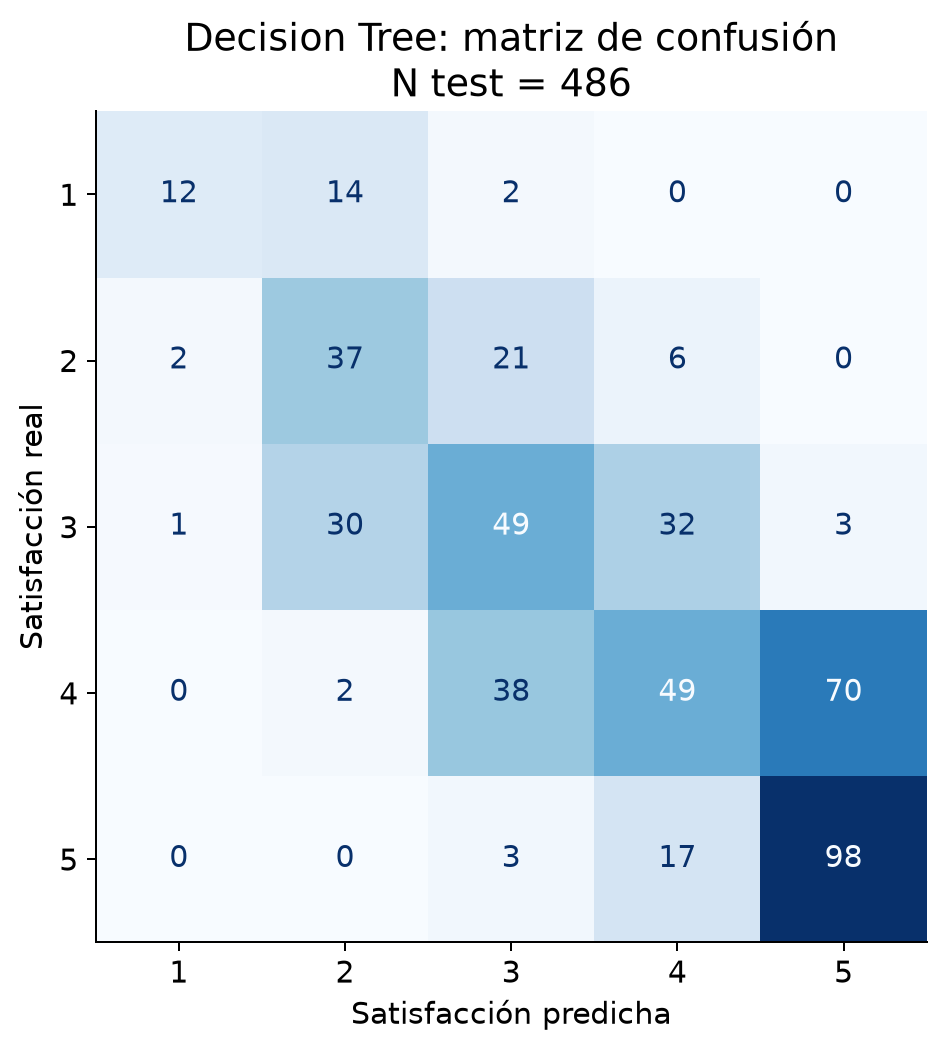

Confusiones dirigidas más frecuentes: real 4 → predicho 5: 70; real 4 → predicho 3: 38; real 3 → predicho 4: 32. Errores de exactamente un nivel: 224; de ≥2: 17; extremos 1→5=0, 5→1=0. Menor recall en nivel(es) 4: 0.3082. Los soportes por clase condicionan la estabilidad de estos porcentajes.

## 7. Random Forest

n_estimators=200, criterion='gini', max_depth=10, min_samples_leaf=3, min_samples_split=2, max_features='sqrt', bootstrap=True, n_jobs=1, random_state=42. Se promedian 200 árboles con muestreo bootstrap y subconjuntos de features; límites moderados reducen hojas mínimas. La estructura del conjunto es menos interpretable que un árbol individual.

| Modelo        | Accuracy | Macro Precision | Macro Recall | Macro F1 | MAE ordinal | Exactas % | Dentro de ±1 % | Error >=2 % |
| ------------- | -------: | --------------: | -----------: | -------: | ----------: | --------: | -------------: | ----------: |
| Random Forest |   0.4918 |          0.5044 |       0.4758 |   0.4840 |      0.5412 |   49.1770 |        96.7078 |      3.2922 |

**Classification report (test):**

| Clase/promedio | Precision | Recall | F1     | Support |
| -------------- | --------: | -----: | -----: | ------: |
| 1              |    0.6316 | 0.4286 | 0.5106 |      28 |
| 2              |    0.3966 | 0.3485 | 0.3710 |      66 |
| 3              |    0.4403 | 0.5130 | 0.4739 |     115 |
| 4              |    0.4706 | 0.4025 | 0.4339 |     159 |
| 5              |    0.5827 | 0.6864 | 0.6304 |     118 |
| macro avg      |    0.5044 | 0.4758 | 0.4840 |     486 |
| weighted avg   |    0.4899 | 0.4918 | 0.4869 |     486 |

Accuracy global=0.4918, N test=486.

**Visualización:** Matriz de conteos con orden 1–5; filas reales y columnas predichas permiten localizar confusiones cercanas y extremas.

![matriz_confusion_random_forest.png](../outputs/figuras/modelado/matriz_confusion_random_forest.png)

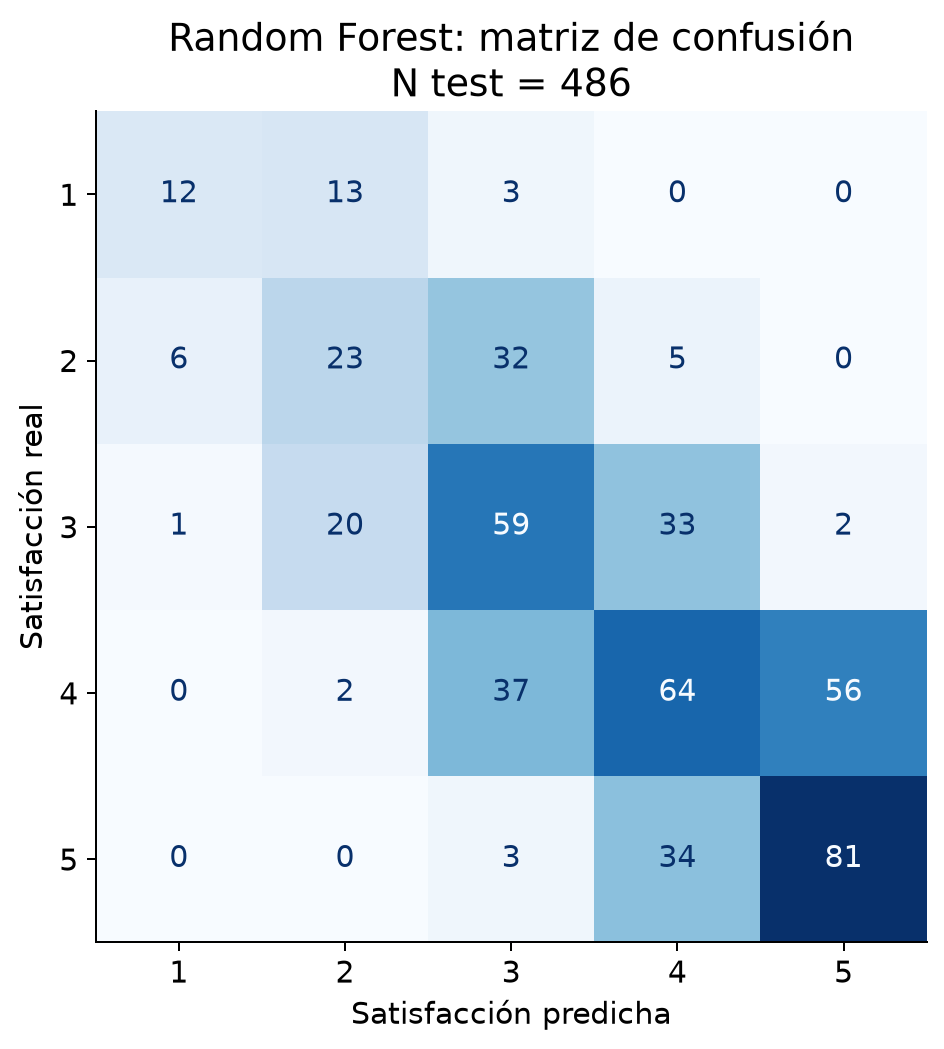

Confusiones dirigidas más frecuentes: real 4 → predicho 5: 56; real 4 → predicho 3: 37; real 5 → predicho 4: 34. Errores de exactamente un nivel: 231; de ≥2: 16; extremos 1→5=0, 5→1=0. Menor recall en nivel(es) 2: 0.3485. Los soportes por clase condicionan la estabilidad de estos porcentajes.

In [3]:
baseline_class=int(y_train.mode().iloc[0])
predictions={"Baseline":np.full(len(y_test),baseline_class,dtype=int)}
predictions.update({name:pipe.predict(X_test) for name,pipe in models.items()})
metric_names=["Accuracy","Macro Precision","Macro Recall","Macro F1","MAE ordinal","Exactas %","Dentro de ±1 %","Error >=2 %"]
metrics,cms,reports={}, {}, {}
for name,pred in predictions.items():
    assert len(pred)==len(y_test) and set(pred)<=set(labels)
    error=np.abs(y_test.to_numpy()-pred)
    metrics[name]=[accuracy_score(y_test,pred),precision_score(y_test,pred,average="macro",labels=labels,zero_division=0),
                   recall_score(y_test,pred,average="macro",labels=labels,zero_division=0),
                   f1_score(y_test,pred,average="macro",labels=labels,zero_division=0),
                   mean_absolute_error(y_test,pred),100*np.mean(error==0),100*np.mean(error<=1),100*np.mean(error>=2)]
    cm=confusion_matrix(y_test,pred,labels=labels)
    assert cm.shape==(5,5) and cm.sum()==len(y_test)
    assert np.isclose(np.trace(cm)/len(y_test),metrics[name][0])
    assert np.isclose(error.mean(),metrics[name][4]) and np.isclose(metrics[name][6]+metrics[name][7],100)
    cms[name]=cm
    reports[name]=classification_report(y_test,pred,labels=labels,target_names=list(map(str,labels)),output_dict=True,zero_division=0)
emit("## 5. Baseline\n\n"
     f"Se predice siempre la clase **{baseline_class}**, la más frecuente de train "
     f"({int(y_train.eq(baseline_class).sum())}/{len(y_train)}). No es un tercer modelo principal.\n\n"+
     table(["Estrategia",*metric_names],[["Baseline",*metrics["Baseline"]]],numeric=tuple(range(1,9)))+
     "\n\nDentro de ±1 incluye aciertos exactos. Las métricas macro dan igual peso a cada clase. "
     "Cuando una clase no recibe predicciones, su precisión se registra como 0 con zero_division=0.")
configs={
"Decision Tree":"criterion='gini', max_depth=6, min_samples_leaf=10, min_samples_split=2, random_state=42. "
                "Se limita profundidad y tamaño mínimo de hoja para reducir particiones pequeñas y facilitar lectura del árbol. No se busca el máximo ajuste de train.",
"Random Forest":"n_estimators=200, criterion='gini', max_depth=10, min_samples_leaf=3, min_samples_split=2, max_features='sqrt', bootstrap=True, n_jobs=1, random_state=42. "
                "Se promedian 200 árboles con muestreo bootstrap y subconjuntos de features; límites moderados reducen hojas mínimas. La estructura del conjunto es menos interpretable que un árbol individual."
}
error_notes={}
for section,name,file in [(6,"Decision Tree","matriz_confusion_decision_tree.png"),(7,"Random Forest","matriz_confusion_random_forest.png")]:
    emit(f"## {section}. {name}\n\n"+configs[name]+"\n\n"+
         table(["Modelo",*metric_names],[[name,*metrics[name]]],numeric=tuple(range(1,9))))
    rows=[]
    for key in ["1","2","3","4","5","macro avg","weighted avg"]:
        r=reports[name][key]
        rows.append([key,r["precision"],r["recall"],r["f1-score"],int(r["support"])])
    emit("**Classification report (test):**\n\n"+table(["Clase/promedio","Precision","Recall","F1","Support"],rows,numeric=(1,2,3,4))+
         f"\n\nAccuracy global={reports[name]['accuracy']:.4f}, N test={len(y_test)}.")
    fig,ax=plt.subplots(figsize=(7.5,6))
    ConfusionMatrixDisplay(cms[name],display_labels=labels).plot(ax=ax,cmap="Blues",colorbar=False,values_format="d")
    ax.set(title=f"{name}: matriz de confusión\nN test = {len(y_test)}",xlabel="Satisfacción predicha",ylabel="Satisfacción real")
    save(fig,ax,file,"Matriz de conteos con orden 1–5; filas reales y columnas predichas permiten localizar confusiones cercanas y extremas.")
    cm=cms[name]
    pairs=sorted([(int(cm[i,j]),labels[i],labels[j]) for i in range(5) for j in range(5) if i!=j],reverse=True)
    top=[f"real {real} → predicho {pred}: {count}" for count,real,pred in pairs[:3] if count>0]
    err=np.abs(y_test.to_numpy()-predictions[name])
    recalls=np.array([reports[name][str(k)]["recall"] for k in labels])
    weakest=[str(k) for k,r in zip(labels,recalls) if np.isclose(r,recalls.min())]
    note=(f"Confusiones dirigidas más frecuentes: {'; '.join(top)}. "
          f"Errores de exactamente un nivel: {int((err==1).sum())}; de ≥2: {int((err>=2).sum())}; "
          f"extremos 1→5={cm[0,4]}, 5→1={cm[4,0]}. "
          f"Menor recall en nivel(es) {', '.join(weakest)}: {recalls.min():.4f}.")
    error_notes[name]=note
    emit(note+" Los soportes por clase condicionan la estabilidad de estos porcentajes.")


## 8. Comparación de modelos

| Modelo        | Accuracy | Macro Precision | Macro Recall | Macro F1 | MAE ordinal | Exactas % | Dentro de ±1 % | Error >=2 % |
| ------------- | -------: | --------------: | -----------: | -------: | ----------: | --------: | -------------: | ----------: |
| Baseline      |   0.3272 |          0.0654 |       0.2000 |   0.0986 |      0.9239 |   32.7160 |        80.6584 |     19.3416 |
| Decision Tree |   0.5041 |          0.5447 |       0.5108 |   0.5071 |      0.5309 |   50.4115 |        96.5021 |      3.4979 |
| Random Forest |   0.4918 |          0.5044 |       0.4758 |   0.4840 |      0.5412 |   49.1770 |        96.7078 |      3.2922 |

**Criterio fijado antes de evaluar:** entre los dos modelos, sumar los rangos de macro F1 (mayor es mejor), MAE ordinal (menor) y porcentaje de errores ≥2 (menor). Si hay empate se elige menor DE de macro F1 en CV de train y, si persiste, Decision Tree por interpretabilidad. Accuracy se informa, pero no decide. La matriz de confusión se revisa para identificar clases difíciles y errores extremos.

| Modelo        | Rango F1 | Rango MAE | Rango errores ≥2 | Suma de rangos |
| ------------- | -------: | --------: | ---------------: | -------------: |
| Decision Tree |   1.0000 |    1.0000 |           2.0000 |         4.0000 |
| Random Forest |   2.0000 |    2.0000 |           1.0000 |         5.0000 |

**Modelo seleccionado para análisis posterior: Decision Tree.** Confusiones dirigidas más frecuentes: real 4 → predicho 5: 70; real 4 → predicho 3: 38; real 3 → predicho 4: 32. Errores de exactamente un nivel: 224; de ≥2: 17; extremos 1→5=0, 5→1=0. Menor recall en nivel(es) 4: 0.3082.

La selección comparativa solicitada usa los resultados de este test una sola vez, sin reajuste. Por eso el test ya no constituye una estimación independiente de la selección del ganador; haría falta otra evaluación externa para confirmarla. La CV de train aporta contexto de estabilidad, sin justificar superioridad poblacional.

**Visualización:** Tres paneles separan macro F1, MAE ordinal y errores grandes en sus propias unidades; no se mezclan porcentajes con niveles en un mismo eje.

![comparacion_modelos.png](../outputs/figuras/modelado/comparacion_modelos.png)

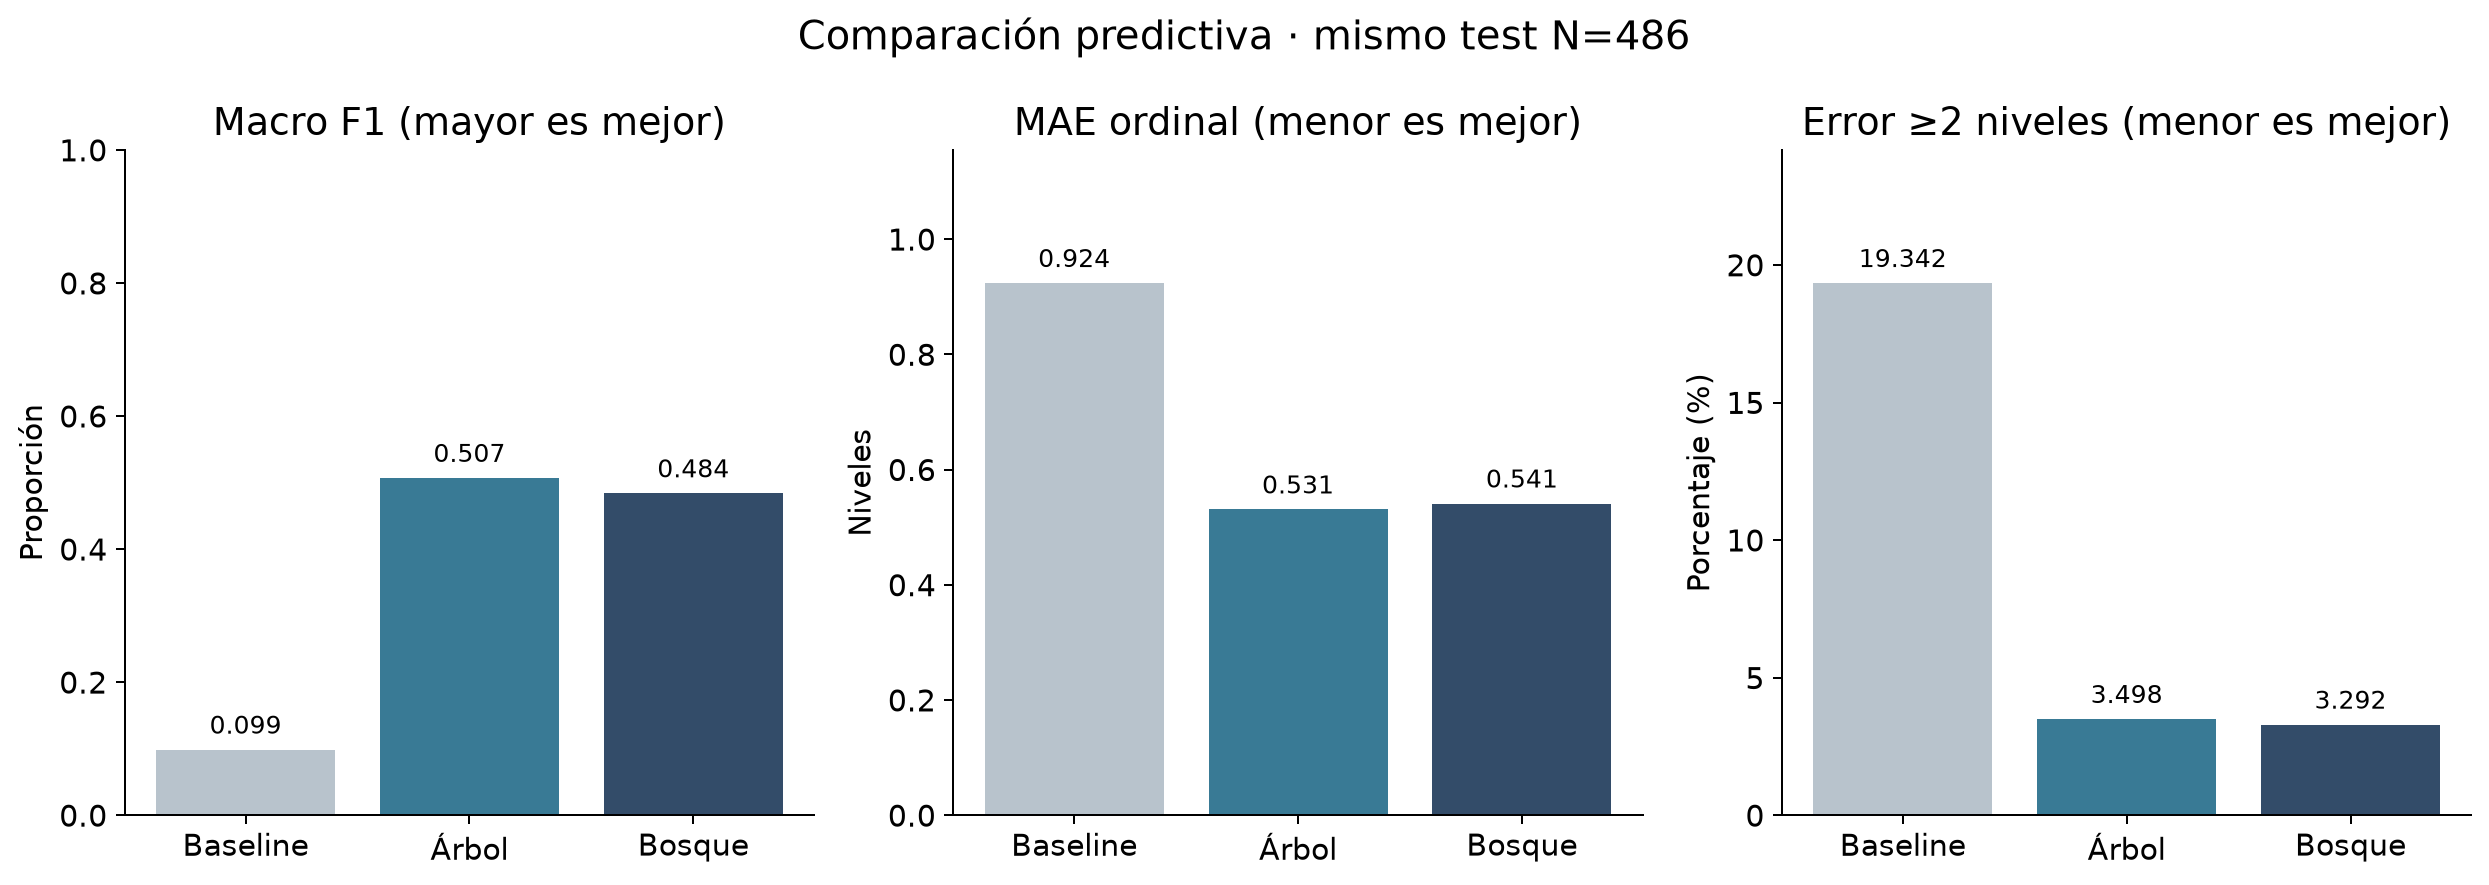

## 9. Análisis ordinal de errores

Modelo: **Decision Tree**; N test=486. MAE ordinal = promedio de |nivel real − nivel predicho| = **0.5309**. La distancia en niveles permite distinguir 5→4 (1) de 5→1 (4), pero no prueba que la escala tenga distancias psicológicas iguales.

| Error absoluto | Cantidad | Porcentaje test |
| -------------: | -------: | --------------: |
|              0 |      245 |         50.4115 |
|              1 |      224 |         46.0905 |
|              2 |       17 |          3.4979 |
|              3 |        0 |          0.0000 |
|              4 |        0 |          0.0000 |

Exactas=50.41%; dentro de ±1=96.50% (incluye exactas); error ≥2=3.50% (17 casos); errores extremos=0.

Errores grandes por nivel real (porcentaje dentro de cada nivel, no del test total):

| Nivel real | N test | Error ≥2 (n) | Error ≥2 (%) |
| ---------: | -----: | -----------: | -----------: |
|          1 |     28 |            2 |       7.1429 |
|          2 |     66 |            6 |       9.0909 |
|          3 |    115 |            4 |       3.4783 |
|          4 |    159 |            2 |       1.2579 |
|          5 |    118 |            3 |       2.5424 |

No se muestran IDs ni se construyen reglas nuevas a partir de los errores.

**Visualización:** Barras 0–4 distinguen aciertos, errores vecinos y saltos grandes; complementan la matriz sin ocultar errores poco frecuentes.

![distribucion_error_ordinal.png](../outputs/figuras/modelado/distribucion_error_ordinal.png)

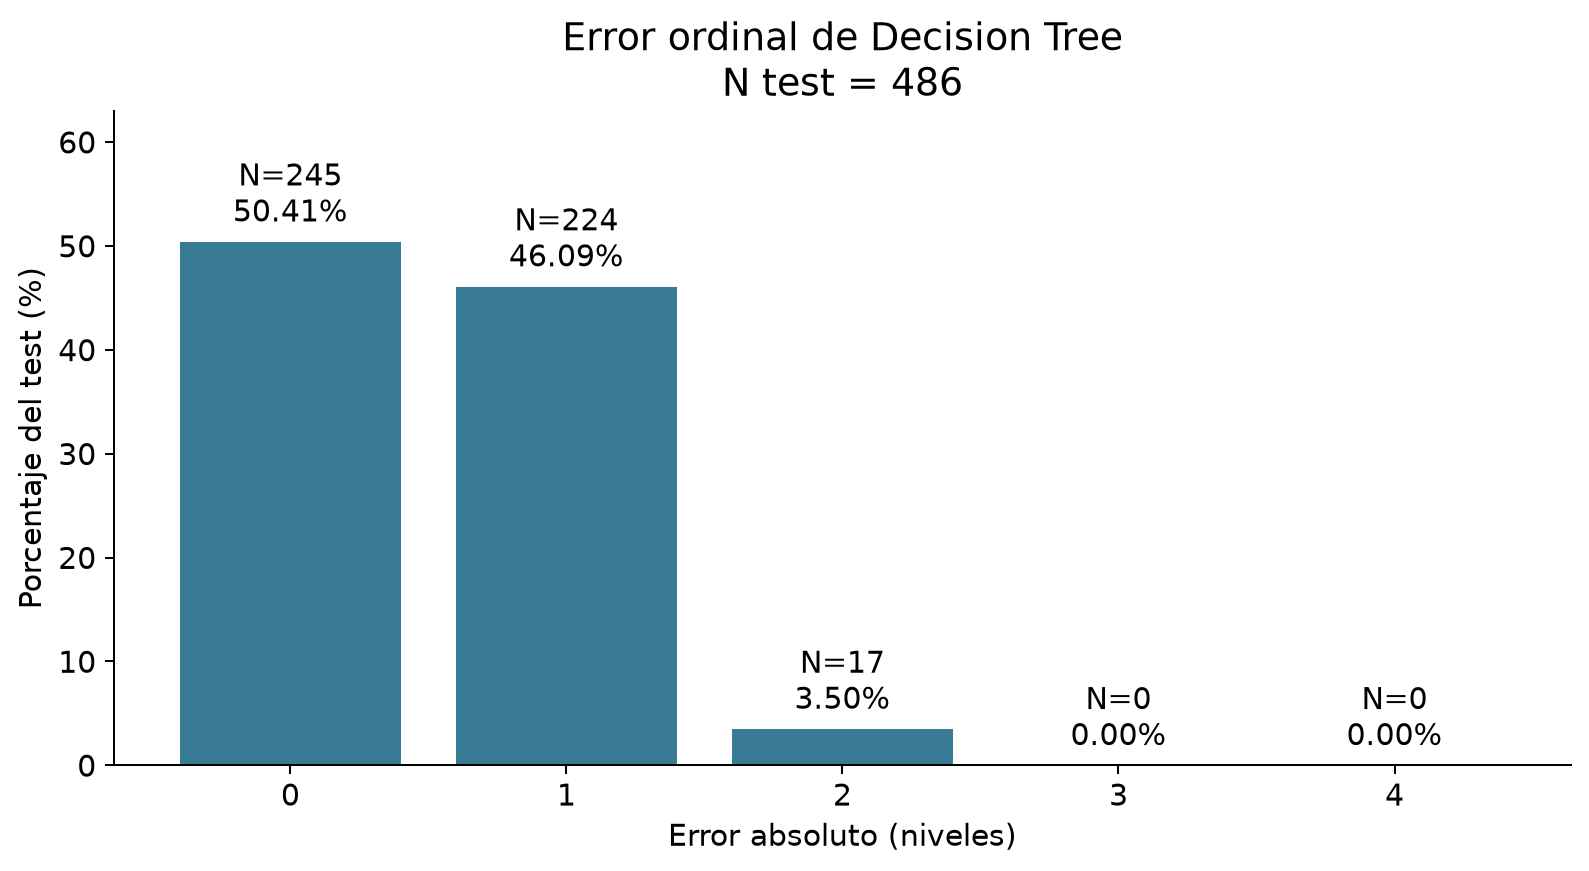

In [4]:
emit("## 8. Comparación de modelos\n\n"+
     table(["Modelo",*metric_names],[[name,*values] for name,values in metrics.items()],numeric=tuple(range(1,9))))
comparison=pd.DataFrame.from_dict(metrics,orient="index",columns=metric_names)
main=comparison.loc[list(models)].copy()
ranks=pd.DataFrame({"F1":main["Macro F1"].rank(ascending=False),"MAE":main["MAE ordinal"].rank(),"Grandes":main["Error >=2 %"].rank()})
rank_sum=ranks.sum(axis=1)
candidates=rank_sum[rank_sum==rank_sum.min()].index.tolist()
selected=sorted(candidates,key=lambda name:(cv_summary[name][1],0 if name=="Decision Tree" else 1))[0]
emit("**Criterio fijado antes de evaluar:** entre los dos modelos, sumar los rangos de macro F1 (mayor es mejor), MAE ordinal (menor) y porcentaje de errores ≥2 (menor). "
     "Si hay empate se elige menor DE de macro F1 en CV de train y, si persiste, Decision Tree por interpretabilidad. Accuracy se informa, pero no decide. "
     "La matriz de confusión se revisa para identificar clases difíciles y errores extremos.\n\n"+
     table(["Modelo","Rango F1","Rango MAE","Rango errores ≥2","Suma de rangos"],[[name,*ranks.loc[name],rank_sum[name]] for name in ranks.index],numeric=(1,2,3,4))+
     f"\n\n**Modelo seleccionado para análisis posterior: {selected}.** "+error_notes[selected]+
     "\n\nLa selección comparativa solicitada usa los resultados de este test una sola vez, sin reajuste. "
     "Por eso el test ya no constituye una estimación independiente de la selección del ganador; haría falta otra evaluación externa para confirmarla. "
     "La CV de train aporta contexto de estabilidad, sin justificar superioridad poblacional.")
fig,axes=plt.subplots(1,3,figsize=(14,5))
names=list(metrics)
for ax,col,title in zip(axes,["Macro F1","MAE ordinal","Error >=2 %"],["Macro F1 (mayor es mejor)","MAE ordinal (menor es mejor)","Error ≥2 niveles (menor es mejor)"]):
    values=comparison.loc[names,col].to_numpy()
    bars=ax.bar(["Baseline","Árbol","Bosque"],values,color=["#B8C3CC","#397A95","#334C69"])
    ax.bar_label(bars,fmt="%.3f",padding=4,fontsize=10)
    ax.set(title=title,ylabel="Proporción" if col=="Macro F1" else "Niveles" if col=="MAE ordinal" else "Porcentaje (%)",
           ylim=(0,max(1 if col=="Macro F1" else .1,float(values.max())*1.25)))
fig.suptitle(f"Comparación predictiva · mismo test N={len(y_test)}",fontsize=16)
save(fig,axes,"comparacion_modelos.png","Tres paneles separan macro F1, MAE ordinal y errores grandes en sus propias unidades; no se mezclan porcentajes con niveles en un mismo eje.")
emit("## 9. Análisis ordinal de errores")
errors=np.abs(y_test.to_numpy()-predictions[selected])
error_counts=np.bincount(errors.astype(int),minlength=5)
assert error_counts.sum()==len(y_test)
emit(f"Modelo: **{selected}**; N test={len(y_test)}. MAE ordinal = promedio de |nivel real − nivel predicho| = **{errors.mean():.4f}**. "
     "La distancia en niveles permite distinguir 5→4 (1) de 5→1 (4), pero no prueba que la escala tenga distancias psicológicas iguales.\n\n"+
     table(["Error absoluto","Cantidad","Porcentaje test"],[[i,int(error_counts[i]),error_counts[i]/len(y_test)*100] for i in range(5)],numeric=(0,1,2)))
emit(f"Exactas={metrics[selected][5]:.2f}%; dentro de ±1={metrics[selected][6]:.2f}% (incluye exactas); "
     f"error ≥2={metrics[selected][7]:.2f}% ({int((errors>=2).sum())} casos); errores extremos={int(error_counts[4])}.")
byclass=[]
for k in labels:
    mask=y_test.to_numpy()==k
    byclass.append([k,int(mask.sum()),int((errors[mask]>=2).sum()),100*np.mean(errors[mask]>=2)])
emit("Errores grandes por nivel real (porcentaje dentro de cada nivel, no del test total):\n\n"+
     table(["Nivel real","N test","Error ≥2 (n)","Error ≥2 (%)"],byclass,numeric=(0,1,2,3))+
     "\n\nNo se muestran IDs ni se construyen reglas nuevas a partir de los errores.")
fig,ax=plt.subplots(figsize=(9,5))
bars=ax.bar(range(5),error_counts/len(y_test)*100,color="#397A95")
ax.bar_label(bars,labels=[f"N={int(v)}\n{v/len(y_test)*100:.2f}%" for v in error_counts],padding=4)
ax.set(title=f"Error ordinal de {selected}\nN test = {len(y_test)}",xlabel="Error absoluto (niveles)",ylabel="Porcentaje del test (%)",xticks=range(5),ylim=(0,float(error_counts.max()/len(y_test)*100)*1.25))
save(fig,ax,"distribucion_error_ordinal.png","Barras 0–4 distinguen aciertos, errores vecinos y saltos grandes; complementan la matriz sin ocultar errores poco frecuentes.")


## 10. Importancia de variables

Importancias del modelo seleccionado: **Decision Tree**.

**A. Features transformadas:**

| Feature transformada                       | Variable original   | Importancia |
| ------------------------------------------ | ------------------- | ----------: |
| espera__Tiempo_Espera_min                  | Tiempo_Espera_min   |      0.6310 |
| categoricas__Acceso_Medicacion_Sí          | Acceso_Medicacion   |      0.1317 |
| categoricas__Acceso_Medicacion_No          | Acceso_Medicacion   |      0.1299 |
| numericas__Edad                            | Edad                |      0.0404 |
| numericas__Frecuencia_Atencion             | Frecuencia_Atencion |      0.0228 |
| categoricas__Genero_Otro                   | Genero              |      0.0086 |
| categoricas__Cobertura_Salud_Sin cobertura | Cobertura_Salud     |      0.0071 |
| categoricas__Genero_F                      | Genero              |      0.0066 |
| categoricas__Region_Sur                    | Region              |      0.0051 |
| categoricas__Condicion_Salud_Aguda         | Condicion_Salud     |      0.0050 |
| categoricas__Genero_M                      | Genero              |      0.0048 |
| categoricas__Condicion_Salud_Saludable     | Condicion_Salud     |      0.0048 |
| categoricas__Condicion_Salud_Crónica       | Condicion_Salud     |      0.0022 |
| categoricas__Region_Buenos Aires           | Region              |      0.0000 |
| categoricas__Region_CABA                   | Region              |      0.0000 |
| categoricas__Region_Centro                 | Region              |      0.0000 |
| categoricas__Region_Norte                  | Region              |      0.0000 |
| categoricas__Cobertura_Salud_Privada       | Cobertura_Salud     |      0.0000 |
| categoricas__Cobertura_Salud_Pública       | Cobertura_Salud     |      0.0000 |

**B. Variables originales:** las categorías OneHot se asignan mediante categories_ y el orden del ColumnTransformer, sin adivinar nombres por prefijos. Se suman sus importancias y se conservan las numéricas individuales.

| Variable original   | Importancia agregada | Porcentaje |
| ------------------- | -------------------: | ---------: |
| Tiempo_Espera_min   |               0.6310 |    63.1003 |
| Acceso_Medicacion   |               0.2616 |    26.1623 |
| Edad                |               0.0404 |     4.0425 |
| Frecuencia_Atencion |               0.0228 |     2.2755 |
| Genero              |               0.0200 |     2.0038 |
| Condicion_Salud     |               0.0119 |     1.1943 |
| Cobertura_Salud     |               0.0071 |     0.7111 |
| Region              |               0.0051 |     0.5103 |

Suma agregada verificada: **1.000000**. Son reducciones de impureza acumuladas en train, no efectos causales ni aportes independientes. Pueden favorecer variables continuas o con muchas categorías; variables relacionadas pueden repartirse importancia. La suma por variable facilita lectura pero no elimina ese sesgo. [Limitaciones de la importancia por impureza](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html).

**Visualización:** Barras horizontales muestran las ocho variables originales tras sumar categorías OneHot, sin confundir codificaciones individuales con variables sustantivas.

![importancia_variables_modelo.png](../outputs/figuras/modelado/importancia_variables_modelo.png)

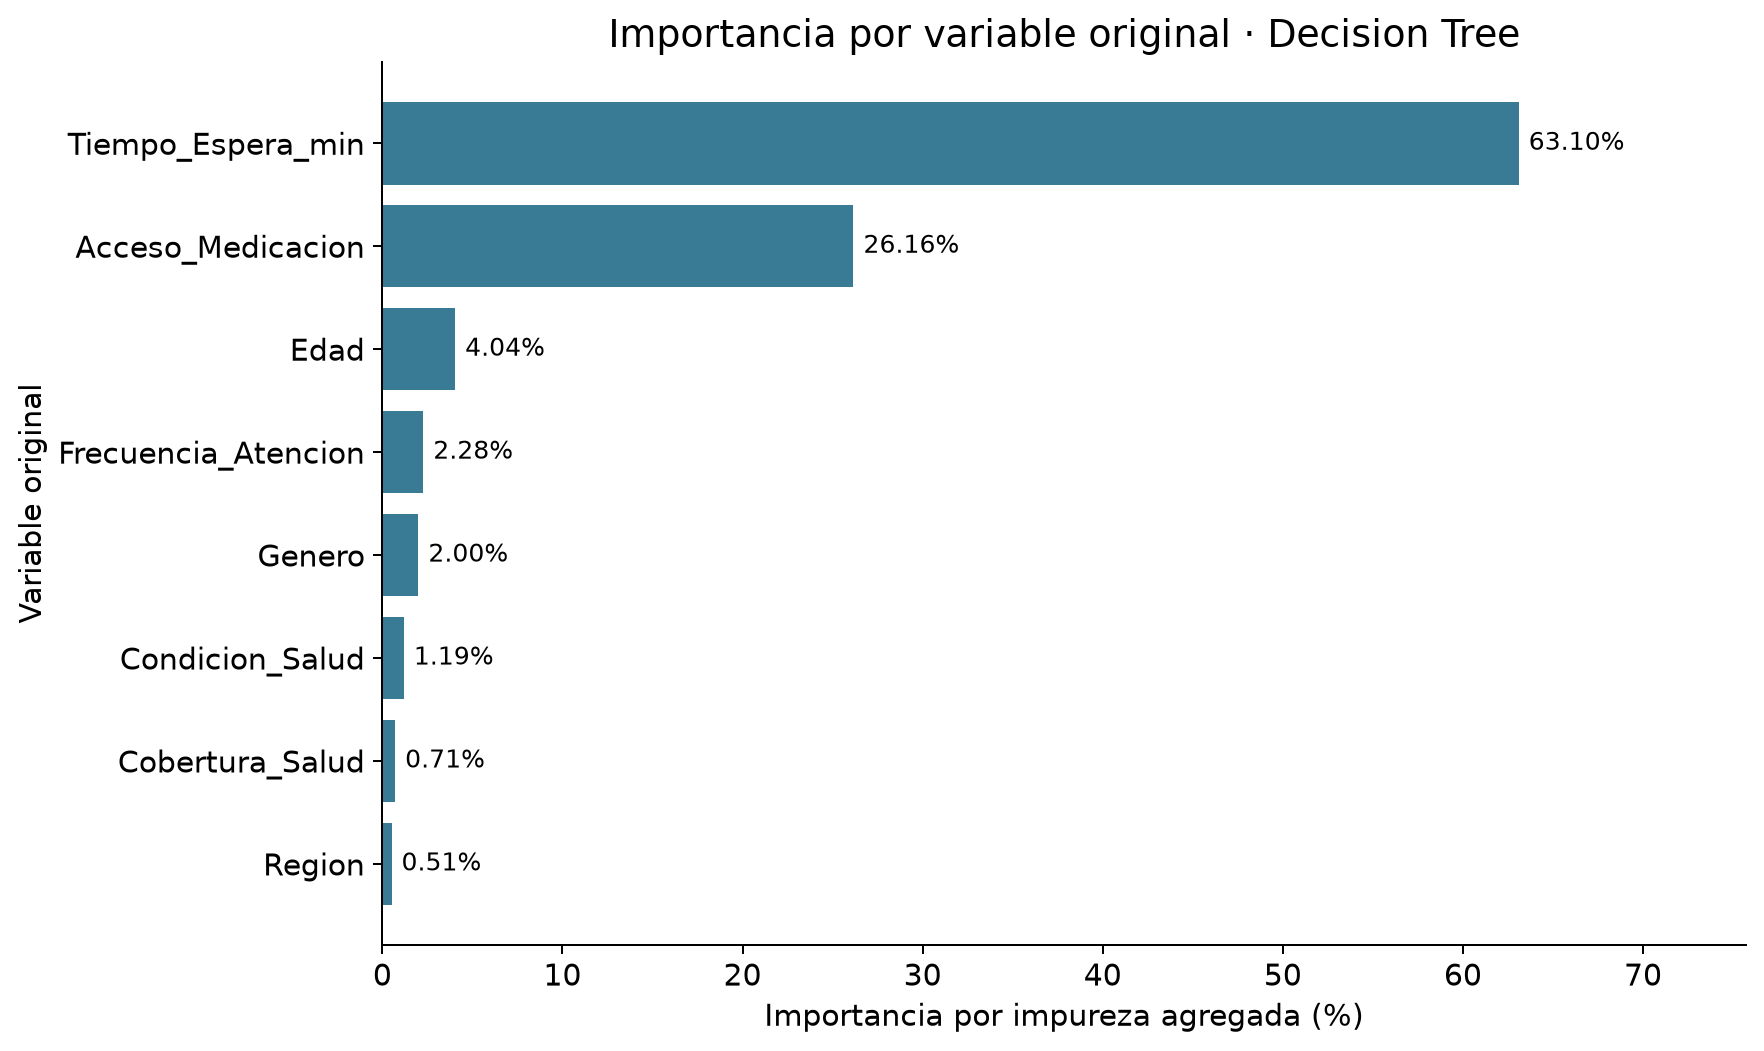

## 11. Interpretación crítica

El modelo seleccionado obtiene macro F1=0.5071 frente a 0.0986 del baseline, y MAE=0.5309 frente a 0.9239. Acertó exactamente en 50.41% y quedó dentro de ±1 en 96.50%; registró 17 errores de ≥2 y 0 extremos. La mejora observada se evalúa conjuntamente, no solo por accuracy; no se realizó una prueba de superioridad entre modelos.

Variables con mayor importancia: Tiempo_Espera_min: 63.10%; Acceso_Medicacion: 26.16%; Edad: 4.04%. La relevancia predictiva observada de espera y acceso es compatible con el EDA y las relaciones sintéticas documentadas; no es un descubrimiento causal ni una validación independiente del generador de datos. La importancia indica uso en particiones del modelo y no necesidad causal.

Decision Tree tiene profundidad realizada 6 y 50 hojas; Random Forest reúne 200 árboles. El árbol ofrece una estructura individual inspeccionable; el bosque tiene mayor complejidad. La CV informa variación dentro de train, pero una semilla y un dataset no prueban estabilidad frente a otros escenarios.

## 12. Hallazgos

### Hallazgo 1

**RESULTADO:** Modelable=2428, train=1942, test=486; 72 targets ausentes excluidos y 71 esperas faltantes retenidas.

**INTERPRETACIÓN:** El flujo permite modelar los casos con etiqueta sin perderlos por NA en espera.

**LIMITACIÓN:** No se aprende de los 72 sin target; se desconoce el mecanismo de ausencia.

### Hallazgo 2

**RESULTADO:** Decision Tree: macro F1=0.5071, MAE=0.5309; baseline F1=0.0986, MAE=0.9239, mismo test N=486.

**INTERPRETACIÓN:** Las métricas permiten contrastar capacidad predictiva con una estrategia trivial.

**LIMITACIÓN:** La selección sobre el test impide tomar la estimación del ganador como evaluación externa independiente.

### Hallazgo 3

**RESULTADO:** Exactas=50.41%; dentro de ±1=96.50%; error ≥2=3.50% (17/486).

**INTERPRETACIÓN:** La evaluación ordinal distingue fallos vecinos de saltos grandes.

**LIMITACIÓN:** La distancia numérica no acredita intervalos iguales de satisfacción.

### Hallazgo 4

**RESULTADO:** Confusiones dirigidas más frecuentes: real 4 → predicho 5: 70; real 4 → predicho 3: 38; real 3 → predicho 4: 32. Errores de exactamente un nivel: 224; de ≥2: 17; extremos 1→5=0, 5→1=0. Menor recall en nivel(es) 4: 0.3082. N test=486.

**INTERPRETACIÓN:** La matriz permite localizar dificultades por clase además del acierto global.

**LIMITACIÓN:** Los niveles con menor soporte tienen estimaciones más variables; no se crean reglas nuevas.

### Hallazgo 5

**RESULTADO:** Tiempo_Espera_min: 63.10%; Acceso_Medicacion: 26.16%; Edad: 4.04%; suma total de importancias=1.0000.

**INTERPRETACIÓN:** El modelo utiliza más estas variables según reducción de impureza en train.

**LIMITACIÓN:** Importancia no equivale a causalidad; puede tener sesgos de cardinalidad y redundancia.

## 13. Limitaciones

Datos ficticios con relaciones incorporadas, sin validación externa ni representatividad. Las etapas exploratorias previas observaron el dataset completo: el split de esta etapa evita leakage de ajuste y preprocesamiento, pero no vuelve completamente ciega la exploración previa. La selección final entre dos modelos usa el mismo test; no se afina después, y se reconoce el posible optimismo de seleccionar al ganador. CV se limita a cinco pliegues de train y no certifica estabilidad en otra población.

Los clasificadores optimizan clases nominales, no una pérdida ordinal; MAE se añade para evaluar distancias en niveles. La mediana de espera simplifica la información ausente y puede reducir variabilidad; se aprende solo con train pero no recupera el valor verdadero. No se analizan calibración, equidad, despliegue o desempeño temporal. Espera y acceso deben estar disponibles al predecir, lo cual limita cualquier lectura prospectiva. No se infiere causalidad, no se proponen decisiones clínicas ni recomendaciones finales.

Entregables: notebooks/07_modelado.ipynb, reports/07_modelado.md y cinco figuras en outputs/figuras/modelado/. No se serializa el modelo. Ejecutar el notebook reproduce entrenamiento, evaluación y figuras.

Entorno: Python 3.12.3, pandas 3.0.5, NumPy 2.5.3, scikit-learn 1.9.1, matplotlib 3.11.2.

In [5]:
emit("## 10. Importancia de variables")
chosen=models[selected]
prep=chosen.named_steps["preprocesamiento"]
feature_names=prep.get_feature_names_out()
# Único acceso a feature_importances_: modelo seleccionado, ajustado con train.
importances=chosen.named_steps["modelo"].feature_importances_
mapping=[]
encoder=prep.named_transformers_["categoricas"]
for column,cats in zip(categorical,encoder.categories_):
    mapping.extend([column]*len(cats))
mapping.extend(numeric_pass)
mapping.append("Tiempo_Espera_min")
assert len(mapping)==len(importances)==len(feature_names)
assert prep.output_indices_["categoricas"]==slice(0,sum(len(c) for c in encoder.categories_))
assert np.all(importances>=0) and np.isclose(importances.sum(),1)
detail=pd.DataFrame({"Feature transformada":feature_names,"Variable original":mapping,"Importancia":importances})
aggregated=detail.groupby("Variable original",sort=False).Importancia.sum().reindex(predictors).sort_values(ascending=False)
assert set(aggregated.index)==set(predictors) and np.isclose(aggregated.sum(),1)
assert np.isclose(aggregated.sum(),detail.Importancia.sum())
emit(f"Importancias del modelo seleccionado: **{selected}**.\n\n**A. Features transformadas:**\n\n"+
     table(["Feature transformada","Variable original","Importancia"],detail.sort_values("Importancia",ascending=False).itertuples(index=False,name=None),numeric=(2,)))
emit("**B. Variables originales:** las categorías OneHot se asignan mediante categories_ y el orden del ColumnTransformer, sin adivinar nombres por prefijos. "
     "Se suman sus importancias y se conservan las numéricas individuales.\n\n"+
     table(["Variable original","Importancia agregada","Porcentaje"],[[k,v,100*v] for k,v in aggregated.items()],numeric=(1,2))+
     f"\n\nSuma agregada verificada: **{aggregated.sum():.6f}**. "
     "Son reducciones de impureza acumuladas en train, no efectos causales ni aportes independientes. "
     "Pueden favorecer variables continuas o con muchas categorías; variables relacionadas pueden repartirse importancia. "
     "La suma por variable facilita lectura pero no elimina ese sesgo. "
     "[Limitaciones de la importancia por impureza](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html).")
fig,ax=plt.subplots(figsize=(10,6))
ordered=aggregated.iloc[::-1]
bars=ax.barh(ordered.index,ordered.to_numpy()*100,color="#397A95")
ax.bar_label(bars,fmt="%.2f%%",padding=4,fontsize=10)
ax.set(title=f"Importancia por variable original · {selected}",xlabel="Importancia por impureza agregada (%)",ylabel="Variable original",xlim=(0,float(ordered.max()*100)*1.2))
save(fig,ax,"importancia_variables_modelo.png","Barras horizontales muestran las ocho variables originales tras sumar categorías OneHot, sin confundir codificaciones individuales con variables sustantivas.")
top3=aggregated.head(3)
top_text="; ".join(f"{k}: {100*v:.2f}%" for k,v in top3.items())
best=metrics[selected]; base=metrics["Baseline"]
emit("## 11. Interpretación crítica\n\n"
     f"El modelo seleccionado obtiene macro F1={best[3]:.4f} frente a {base[3]:.4f} del baseline, y MAE={best[4]:.4f} frente a {base[4]:.4f}. "
     f"Acertó exactamente en {best[5]:.2f}% y quedó dentro de ±1 en {best[6]:.2f}%; registró {int((errors>=2).sum())} errores de ≥2 y {int(error_counts[4])} extremos. "
     "La mejora observada se evalúa conjuntamente, no solo por accuracy; no se realizó una prueba de superioridad entre modelos.\n\n"
     f"Variables con mayor importancia: {top_text}. "
     "La relevancia predictiva observada de espera y acceso es compatible con el EDA y las relaciones sintéticas documentadas; "
     "no es un descubrimiento causal ni una validación independiente del generador de datos. "
     "La importancia indica uso en particiones del modelo y no necesidad causal.\n\n"
     f"Decision Tree tiene profundidad realizada {models['Decision Tree'].named_steps['modelo'].get_depth()} y "
     f"{models['Decision Tree'].named_steps['modelo'].get_n_leaves()} hojas; Random Forest reúne 200 árboles. "
     "El árbol ofrece una estructura individual inspeccionable; el bosque tiene mayor complejidad. La CV informa variación dentro de train, "
     "pero una semilla y un dataset no prueban estabilidad frente a otros escenarios.")
emit("## 12. Hallazgos")
findings=[
(f"Modelable={len(y)}, train={len(y_train)}, test={len(y_test)}; 72 targets ausentes excluidos y 71 esperas faltantes retenidas.",
 "El flujo permite modelar los casos con etiqueta sin perderlos por NA en espera.","No se aprende de los 72 sin target; se desconoce el mecanismo de ausencia."),
(f"{selected}: macro F1={best[3]:.4f}, MAE={best[4]:.4f}; baseline F1={base[3]:.4f}, MAE={base[4]:.4f}, mismo test N={len(y_test)}.",
 "Las métricas permiten contrastar capacidad predictiva con una estrategia trivial.","La selección sobre el test impide tomar la estimación del ganador como evaluación externa independiente."),
(f"Exactas={best[5]:.2f}%; dentro de ±1={best[6]:.2f}%; error ≥2={best[7]:.2f}% ({int((errors>=2).sum())}/{len(y_test)}).",
 "La evaluación ordinal distingue fallos vecinos de saltos grandes.","La distancia numérica no acredita intervalos iguales de satisfacción."),
(error_notes[selected]+f" N test={len(y_test)}.","La matriz permite localizar dificultades por clase además del acierto global.","Los niveles con menor soporte tienen estimaciones más variables; no se crean reglas nuevas."),
(top_text+f"; suma total de importancias={aggregated.sum():.4f}.","El modelo utiliza más estas variables según reducción de impureza en train.","Importancia no equivale a causalidad; puede tener sesgos de cardinalidad y redundancia.")
]
for i,(result,interpretation,limitation) in enumerate(findings,1):
    emit(f"### Hallazgo {i}\n\n**RESULTADO:** {result}\n\n**INTERPRETACIÓN:** {interpretation}\n\n**LIMITACIÓN:** {limitation}")
emit("## 13. Limitaciones\n\n"
     "Datos ficticios con relaciones incorporadas, sin validación externa ni representatividad. Las etapas exploratorias previas observaron el dataset completo: "
     "el split de esta etapa evita leakage de ajuste y preprocesamiento, pero no vuelve completamente ciega la exploración previa. "
     "La selección final entre dos modelos usa el mismo test; no se afina después, y se reconoce el posible optimismo de seleccionar al ganador. "
     "CV se limita a cinco pliegues de train y no certifica estabilidad en otra población.\n\n"
     "Los clasificadores optimizan clases nominales, no una pérdida ordinal; MAE se añade para evaluar distancias en niveles. "
     "La mediana de espera simplifica la información ausente y puede reducir variabilidad; se aprende solo con train pero no recupera el valor verdadero. "
     "No se analizan calibración, equidad, despliegue o desempeño temporal. Espera y acceso deben estar disponibles al predecir, lo cual limita cualquier lectura prospectiva. "
     "No se infiere causalidad, no se proponen decisiones clínicas ni recomendaciones finales.\n\n"
     "Entregables: notebooks/07_modelado.ipynb, reports/07_modelado.md y cinco figuras en outputs/figuras/modelado/. "
     "No se serializa el modelo. Ejecutar el notebook reproduce entrenamiento, evaluación y figuras.\n\n"
     f"Entorno: Python {platform.python_version()}, pandas {pd.__version__}, NumPy {np.__version__}, scikit-learn {sklearn.__version__}, matplotlib {matplotlib.__version__}.")


In [6]:
# Controles finales sobre el flujo y los archivos.
pd.testing.assert_frame_equal(df,snapshot,check_exact=True)
pd.testing.assert_frame_equal(X_test,test_before,check_exact=True)
pd.testing.assert_series_equal(y_test,ytest_before,check_exact=True)
assert set(X.columns)==set(predictors) and len(X.columns)==8
assert len(X_train)==1942 and len(X_test)==486
for k in labels:
    assert abs(y_train.eq(k).mean()-y.eq(k).mean()) < .002
    assert abs(y_test.eq(k).mean()-y.eq(k).mean()) < .002
for name,pipeline in models.items():
    assert pipeline.named_steps["modelo"].random_state==42
    assert isinstance(pipeline.named_steps["preprocesamiento"],ColumnTransformer)
    assert isinstance(pipeline.named_steps["preprocesamiento"].named_transformers_["espera"],SimpleImputer)
    assert isinstance(pipeline.named_steps["preprocesamiento"].named_transformers_["categoricas"],OneHotEncoder)
    assert pipeline.named_steps["preprocesamiento"].named_transformers_["categoricas"].handle_unknown=="ignore"
    assert list(pipeline.feature_names_in_)==predictors
    assert list(pipeline.named_steps["modelo"].classes_)==labels
assert len(figures)==5 and len(findings)==5
for p,digest in hashes.items():
    assert hashlib.sha256(p.read_bytes()).hexdigest()==digest
emit("**Control final aprobado:** split estratificado 42 sin solapamiento; 2428 modelables, 1942 train y 486 test; "
     "encoder e imputador dentro de pipelines, con medianas de cada train verificadas; "
     "test usado solo para predicciones y evaluación comparativa, sin fit ni reajuste posterior; ocho predictores autorizados; "
     "matrices 5×5 en orden 1–5, mismo test para las tres estrategias; "
     "importancia extraída solo del seleccionado y suma agregada igual a 1. "
     "Datos y entregables anteriores intactos por comparación exacta y SHA-256. Sin IDs de pacientes en el informe.\n\n"
     f"SHA-256 del procesado conservado: {hashes[source]}.")
report="\n\n".join(parts)+"\n"
for link in re.findall(r"!\[[^\]]*\]\(([^)]+)\)",report):
    assert (root/"reports"/link).resolve().is_file()
(root/"reports/07_modelado.md").write_text(report,encoding="utf-8")
print("MODELO SELECCIONADO:",selected)
print("METRICAS:",metrics)
print("TOP 3:",top_text)
print("ERRORES >=2:",int((errors>=2).sum()))


**Control final aprobado:** split estratificado 42 sin solapamiento; 2428 modelables, 1942 train y 486 test; encoder e imputador dentro de pipelines, con medianas de cada train verificadas; test usado solo para predicciones y evaluación comparativa, sin fit ni reajuste posterior; ocho predictores autorizados; matrices 5×5 en orden 1–5, mismo test para las tres estrategias; importancia extraída solo del seleccionado y suma agregada igual a 1. Datos y entregables anteriores intactos por comparación exacta y SHA-256. Sin IDs de pacientes en el informe.

SHA-256 del procesado conservado: 6707074a0d805b2fce33f461c10c9335adcb5ab302d960bc0e963db868b983bd.

MODELO SELECCIONADO: Decision Tree
METRICAS: {'Baseline': [0.3271604938271605, 0.0654320987654321, 0.2, 0.0986046511627907, 0.9238683127572016, np.float64(32.71604938271605), np.float64(80.65843621399176), np.float64(19.34156378600823)], 'Decision Tree': [0.5041152263374485, 0.5447329424945432, 0.510789804180886, 0.5070865315550505, 0.5308641975308642, np.float64(50.41152263374485), np.float64(96.50205761316872), np.float64(3.4979423868312756)], 'Random Forest': [0.49176954732510286, 0.5043502454425594, 0.4758112313107377, 0.4839500243548834, 0.5411522633744856, np.float64(49.17695473251029), np.float64(96.70781893004116), np.float64(3.292181069958848)]}
TOP 3: Tiempo_Espera_min: 63.10%; Acceso_Medicacion: 26.16%; Edad: 4.04%
ERRORES >=2: 17
